In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler,LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print(df.isnull().sum())  # Mengecek jumlah missing values di setiap kolom

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
# handling missing value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# mengecek jumlah data yang hilang per kolom
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
## mengatasi missing value dengan menggunakan teknik imputasi mean
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
# Menghitung Z-Score untuk setiap nilai dalam kolom BMI
z_scores = np.abs(stats.zscore(df['bmi']))
print(z_scores)

0       1.001234e+00
1       4.615554e-16
2       4.685773e-01
3       7.154182e-01
4       6.357112e-01
            ...     
5105    4.615554e-16
5106    1.442949e+00
5107    2.217363e-01
5108    4.278451e-01
5109    3.498953e-01
Name: bmi, Length: 5110, dtype: float64


In [ ]:
# menampilkan semua baris yang memiliki nilai bmi yang outlier
threshold = 3 # batas outlier
outliers = df[z_scores > threshold] # menyaring hanya baris dengan z-score > 3
print(outliers)

         id  gender   age  hypertension  heart_disease ever_married  \
113   41069  Female  45.0             0              0          Yes   
258   28674  Female  74.0             1              0          Yes   
270   72911  Female  57.0             1              0          Yes   
333    1703  Female  52.0             0              0          Yes   
358   66333    Male  52.0             0              0          Yes   
430   53144  Female  52.0             0              1          Yes   
466    1307  Female  61.0             1              0          Yes   
544     545    Male  42.0             0              0          Yes   
637    3130  Female  56.0             0              0          Yes   
662   23551    Male  28.0             0              0          Yes   
672   31145  Female  17.0             0              0           No   
715    3590  Female  28.0             1              0           No   
761    4169  Female  37.0             0              0           No   
805   

In [ ]:
# Membuat dataset baru tanpa outlier
df_no_outliers = df[z_scores <= threshold]

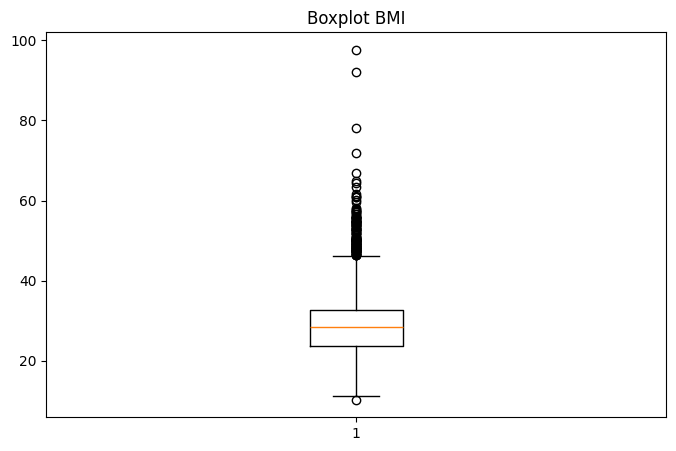

In [ ]:
# visualisasi outlier bmi
plt.figure(figsize=(8,5))
plt.boxplot(df['bmi'])
plt.title('Boxplot BMI')
plt.show()

jika ada titik yang berada jauh di luar batas whisker pada boxplot, maka data tersebut merupakan outlier

In [ ]:
mean_bmi_before = df['bmi'].mean()
mean_bmi_after = df_no_outliers['bmi'].mean()

print("\nBMI Min & Max Sebelum Filter:", df['bmi'].min(), "-", df['bmi'].max())
print("BMI Min & Max Outliers:", outliers['bmi'].min(), "-", outliers['bmi'].max())
print("BMI Min & Max Setelah Filter:", df_no_outliers['bmi'].min(), "-", df_no_outliers['bmi'].max())


BMI Min & Max Sebelum Filter: 10.3 - 97.6
BMI Min & Max Outliers: 52.3 - 97.6
BMI Min & Max Setelah Filter: 10.3 - 51.9


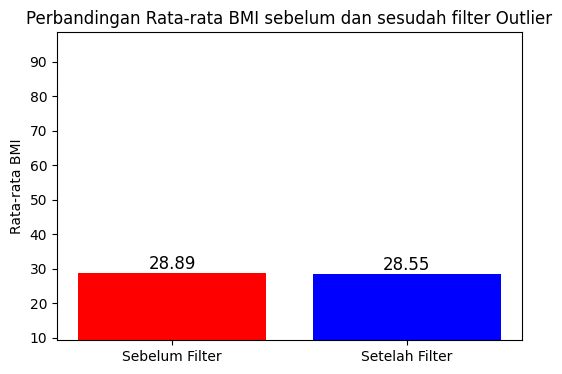

In [ ]:
# visualisasi bar chart
labels = ['Sebelum Filter', 'Setelah Filter']
values = [mean_bmi_before, mean_bmi_after]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=['red', 'blue'])

# tambahkan nilai di atas masing-masing batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,2),
             ha= 'center', va='bottom', fontsize=12)

plt.title("Perbandingan Rata-rata BMI sebelum dan sesudah filter Outlier")
plt.ylabel("Rata-rata BMI")
plt.ylim(df['bmi'].min() - 1, df['bmi'].max() + 1)
plt.show()

In [ ]:
# inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi hanya untuk kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns  # Ambil hanya kolom numerik
df_normalized = df.copy()  # Salin dataset agar tidak merusak data asli
df_normalized[numerical_cols] = scaler.fit_transform(df[numerical_cols])  # Lakukan normalisasi

# Menampilkan hasil seperti gambar
print("Original Data:\n")
print(df.head())  # Menampilkan 5 baris pertama sebelum normalisasi

print("\nNormalized Data:\n")
print(df_normalized.head())  # Menampilkan 5 baris pertama setelah normalisasi

Original Data:

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level        bmi  \
0        Private          Urban             228.69  36.600000   
1  Self-employed          Rural             202.21  28.893237   
2        Private          Rural             105.92  32.500000   
3        Private          Urban             171.23  34.400000   
4  Self-employed          Rural             174.12  24.000000   

    smoking_status  stroke  
0  formerly smoked       1  
1     never smoked       1  
2     never smoked       1  
3           smokes       1  
4     never smoked       1  

Normalize

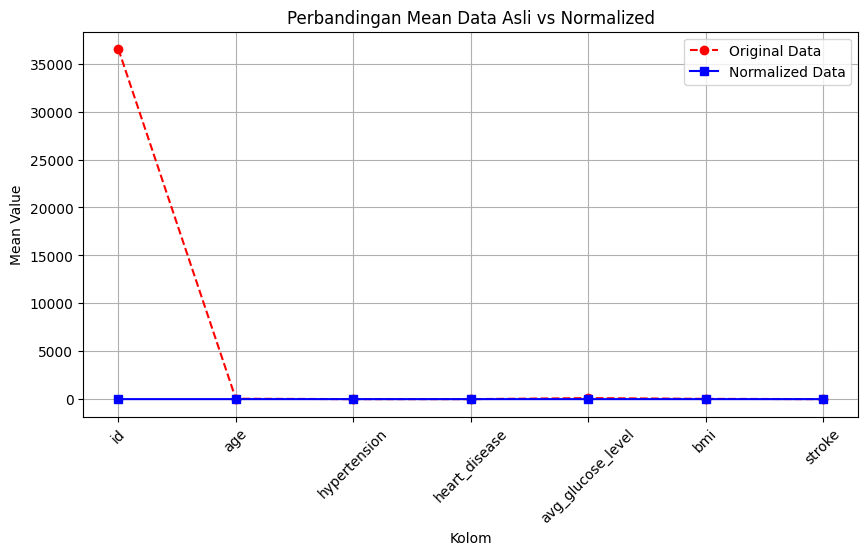

In [ ]:
# Plot data sebelum dan sesudah normalisasi
plt.figure(figsize=(10,5))
plt.plot(df[numerical_cols].mean(), label="Original Data", marker='o', linestyle='dashed', color='red')
plt.plot(df_normalized[numerical_cols].mean(), label="Normalized Data", marker='s', linestyle='solid', color='blue')

plt.title("Perbandingan Mean Data Asli vs Normalized")
plt.xlabel("Kolom")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

#Klasifikasi Random Forest

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['stroke'])  # Semua kolom kecuali stroke
y = df['stroke']  # Target label

In [ ]:
# Membagi data menjadi training (90%) dan testing (10%) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [ ]:
# HAPUS KOLOM ID SEBELUM PREPROCESSING (TARUH DI SINI!)
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

In [ ]:
print(X_train.dtypes)

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
dtype: object


In [ ]:
# Label Encoding untuk Kolom dengan 2 Kategori
label_cols = ['gender', 'ever_married', 'Residence_type']
le = LabelEncoder()

for col in label_cols:
    X_train[col] = le.fit_transform(X_train[col].copy())
    X_test[col] = le.transform(X_test[col].copy())  # Pakai transform, bukan fit_transform


In [ ]:
# Pastikan kolom masih ada sebelum One-Hot Encoding
ohe_cols = [col for col in ['work_type', 'smoking_status'] if col in X_train.columns]

# One-Hot Encoding jika masih ada
if ohe_cols:
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))
    X_test_ohe = pd.DataFrame(ohe.transform(X_test[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))

    # Hapus kolom kategori asli dan gabungkan hasil encoding
    X_train = X_train.drop(columns=ohe_cols).reset_index(drop=True)
    X_test = X_test.drop(columns=ohe_cols).reset_index(drop=True)
    X_train = pd.concat([X_train, X_train_ohe], axis=1)
    X_test = pd.concat([X_test, X_test_ohe], axis=1)


In [ ]:
print("Data setelah encoding:\n", X_train.dtypes)

Data setelah encoding:
 gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
Residence_type                      int64
avg_glucose_level                 float64
bmi                               float64
work_type_Never_worked            float64
work_type_Private                 float64
work_type_Self-employed           float64
work_type_children                float64
smoking_status_formerly smoked    float64
smoking_status_never smoked       float64
smoking_status_smokes             float64
dtype: object


In [ ]:
# Terapkan SMOTE setelah encoding
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
# Periksa apakah data sudah seimbang setelah SMOTE
print("Distribusi sebelum SMOTE:", dict(pd.Series(y_train).value_counts()))
print("Distribusi setelah SMOTE:", dict(pd.Series(y_train_resampled).value_counts()))

Distribusi sebelum SMOTE: {0: 4375, 1: 4375}
Distribusi setelah SMOTE: {0: 4375, 1: 4375}


In [ ]:
# Model Random Forest
rf = RandomForestClassifier(random_state=42)

In [ ]:
# Definisikan hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

In [ ]:
# Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,  # Jumlah kombinasi yang diuji
    cv=3,  # 3-fold cross-validation
    verbose=1,
    n_jobs=-1,  # Gunakan semua core CPU
    random_state=42
)

In [ ]:
# Jalankan pencarian hyperparameter
random_search.fit(X_train_resampled, y_train_resampled)

# Gunakan model terbaik
best_model = random_search.best_estimator_

# Prediksi pada data uji
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
# Evaluasi Model
print("\nEvaluasi Model:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Evaluasi Model:
Accuracy: 0.9510763209393346
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       486
           1       1.00      0.00      0.00        25

    accuracy                           0.95       511
   macro avg       0.98      0.50      0.49       511
weighted avg       0.95      0.95      0.93       511

Confusion Matrix:
 [[486   0]
 [ 25   0]]


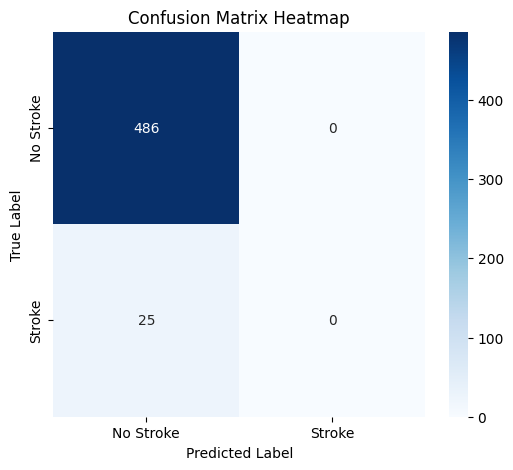

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()